# C6 example 1/4: `WELinear`

One node carries three physical 3D vectors and two scalars. C6 rotates around the z axis, so each 3D vector restricts as

$$\mathbb{R}^3\downarrow_{C_6}=E_1\oplus A,$$

where $E_1=(x,y)$ is the 2D frequency-1 irrep and $A=z$ is trivial. Therefore the input is $3E_1\oplus5A$ (three z components plus two scalar features), and the output is $E_1\oplus4A$ (one z component plus three scalars).

This notebook uses only affine intertwiners. No geometric direction or harmonics are needed because `WELinear` maps one representation-valued feature vector to another.

In [1]:
import math
import torch
from we3nn import CyclicGroup, nn

torch.manual_seed(7)
torch.set_printoptions(precision=5, sci_mode=False)
G = CyclicGroup(6)
A = G.trivial_representation
E1 = G.standard_representation
regular = G.regular_representation()

# Packed layout: [v1_x,v1_y, v2_x,v2_y, v3_x,v3_y, v1_z,v2_z,v3_z, s1,s2].
input_rep = 3 * E1 + 5 * A
hidden_rep = 2 * regular
# Packed layout: [out_v_x,out_v_y, out_v_z, out_s1,out_s2,out_s3].
output_rep = E1 + 4 * A
print('dimensions:', input_rep.size, '->', hidden_rep.size, '->', output_rep.size)

dimensions: 11 -> 12 -> 6


In [2]:
def pack_input(vectors, scalars):
    # vectors: (..., 3, 3); scalars: (..., 2)
    xy = vectors[..., :, :2].reshape(*vectors.shape[:-2], 6)
    z = vectors[..., :, 2]
    return torch.cat((xy, z, scalars), dim=-1)

def unpack_input(x):
    xy = x[..., :6].reshape(*x.shape[:-1], 3, 2)
    z = x[..., 6:9]
    return torch.cat((xy, z.unsqueeze(-1)), dim=-1), x[..., 9:11]

def unpack_output(y):
    vector = torch.cat((y[..., :2], y[..., 2:3]), dim=-1)
    return vector, y[..., 3:6]

vectors = torch.tensor([[[1.0, 0.2, -0.4], [-0.3, 0.8, 1.2], [0.5, -0.7, 0.1]]])
scalars = torch.tensor([[0.6, -1.1]])
x = nn.RepresentationTensor(pack_input(vectors, scalars), input_rep)
print('packed input:', x.tensor)

packed input: tensor([[ 1.00000,  0.20000, -0.30000,  0.80000,  0.50000, -0.70000, -0.40000,
          1.20000,  0.10000,  0.60000, -1.10000]])


## Step 1: visualize the physical input

The three arrows are the three vector-valued node features. The two scalar features have no direction, so they are printed rather than drawn.

scalar node features: [0.6000000238418579, -1.100000023841858]


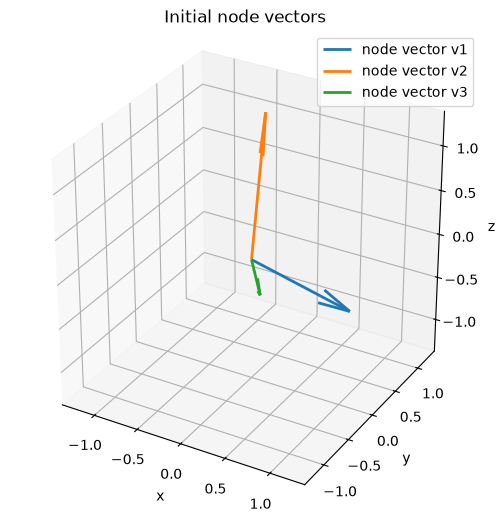

In [3]:
import matplotlib.pyplot as plt

fig_input = plt.figure(figsize=(6, 5), constrained_layout=True)
ax = fig_input.add_subplot(111, projection='3d')
for index, vector in enumerate(vectors[0]):
    ax.quiver(0, 0, 0, *vector.tolist(), color=f'C{index}', linewidth=2, label=f'node vector v{index+1}')
limit = 1.15 * vectors.abs().max().item()
ax.set(xlim=(-limit, limit), ylim=(-limit, limit), zlim=(-limit, limit), xlabel='x', ylabel='y', zlabel='z', title='Initial node vectors')
ax.set_box_aspect((1, 1, 1)); ax.legend()
print('scalar node features:', scalars[0].tolist())
plt.show()

## Step 2: build the architecture

The two learnable maps are complete bases of $C_6$ intertwiners:

$$x\xrightarrow{W_1}2\,\mathrm{Reg}_{C_6}\xrightarrow{\mathrm{ReLU}}2\,\mathrm{Reg}_{C_6}\xrightarrow{W_2}y.$$

A regular representation is a permutation representation, so coordinatewise ReLU (`PointActiv`) commutes with the group action.

In [4]:
class WELinearNetwork(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.input_layer = nn.WELinear(input_rep, hidden_rep)
        self.activation = nn.PointActiv(hidden_rep, torch.relu)
        self.output_layer = nn.WELinear(hidden_rep, output_rep)

    def forward(self, features):
        h_pre = self.input_layer(features)
        h = self.activation(h_pre)
        return self.output_layer(h), h_pre, h

model = WELinearNetwork().eval()
y, h_pre, h = model(x)
print('hidden before PointActiv:', h_pre.tensor)
print('hidden after  PointActiv:', h.tensor)
print('packed output:', y.tensor)
print('physical output (vector, scalars):', unpack_output(y.tensor))

hidden before PointActiv: tensor([[-0.19867,  0.06272,  0.07470, -0.17471, -0.43609, -0.44807,  0.55548,
          0.34676,  0.26490,  0.39178,  0.60050,  0.68235]],
       grad_fn=<AddmmBackward0>)
hidden after  PointActiv: tensor([[0.00000, 0.06272, 0.07470, 0.00000, 0.00000, 0.00000, 0.55548, 0.34676,
         0.26490, 0.39178, 0.60050, 0.68235]], grad_fn=<ReluBackward0>)
packed output: tensor([[ 0.07390, -0.08825,  0.12261, -0.09335,  0.27694,  0.45038]],
       grad_fn=<AddmmBackward0>)
physical output (vector, scalars): (tensor([[ 0.07390, -0.08825,  0.12261]], grad_fn=<CatBackward0>), tensor([[-0.09335,  0.27694,  0.45038]], grad_fn=<SliceBackward0>))


## Step 3: run all six rotations and test equivariance

For each $g=r^k$, we compute the network again on $\rho_{in}(g)x$ and compare it with $\rho_{out}(g)f(x)$. The printed input/output vectors are reconstructed as ordinary 3D vectors; scalar columns are unchanged by C6.

In [5]:
errors = []
for k, element in enumerate(G.elements):
    x_k = x.transform_fibers(element)
    y_k, _, _ = model(x_k)
    expected_k = y.transform_fibers(element)
    error = (y_k.tensor - expected_k.tensor).abs().max().item()
    errors.append(error)
    torch.testing.assert_close(y_k.tensor, expected_k.tensor, atol=2e-5, rtol=2e-5)
    in_vectors_k, in_scalars_k = unpack_input(x_k.tensor)
    out_vector_k, out_scalars_k = unpack_output(y_k.tensor)
    print(f'rotation {k}: angle={60*k:3d} degrees')
    print('  input vectors :', in_vectors_k[0].tolist())
    print('  input scalars :', in_scalars_k[0].tolist())
    print('  output vector :', out_vector_k[0].tolist())
    print('  output scalars:', out_scalars_k[0].tolist())
    print(f'  max equivariance error: {error:.3e}')

print('maximum over all rotations:', max(errors))

rotation 0: angle=  0 degrees
  input vectors : [[1.0, 0.20000000298023224, -0.4000000059604645], [-0.30000001192092896, 0.800000011920929, 1.2000000476837158], [0.5, -0.699999988079071, 0.10000000149011612]]
  input scalars : [0.6000000238418579, -1.100000023841858]
  output vector : [0.07389819622039795, -0.08824879676103592, 0.12261292338371277]
  output scalars: [-0.09334588050842285, 0.27693766355514526, 0.45038193464279175]
  max equivariance error: 0.000e+00
rotation 1: angle= 60 degrees
  input vectors : [[0.32679492235183716, 0.9660254120826721, -0.4000000059604645], [-0.8428202867507935, 0.14019238948822021, 1.2000000476837158], [0.8562177419662476, 0.08301270008087158, 0.10000000149011612]]
  input scalars : [0.6000000238418579, -1.100000023841858]
  output vector : [0.11337476223707199, 0.019873321056365967, 0.12261289358139038]
  output scalars: [-0.09334588795900345, 0.2769376039505005, 0.45038193464279175]
  max equivariance error: 5.960e-08
rotation 2: angle=120 degrees

## Step 4: visualize the hidden regular representations

Each heatmap row is the hidden state after rotating the input. C6 acts on each regular representation by cyclically permuting its six coordinates. The white divider separates the two copies. This architecture uses no circular or spherical harmonics.

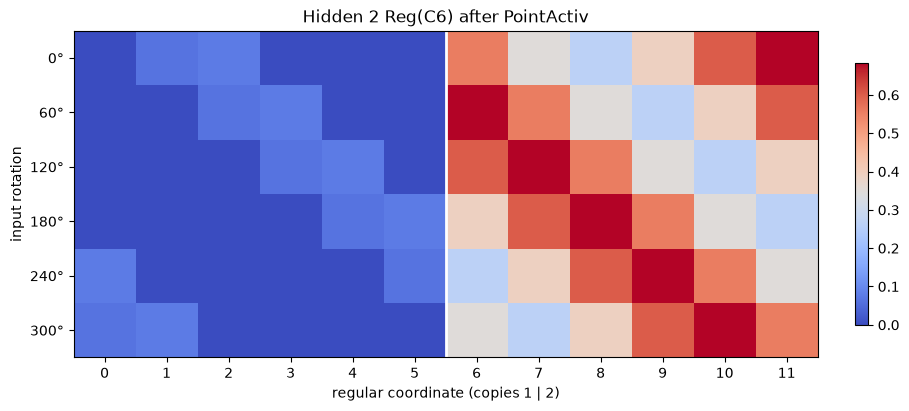

In [6]:
import matplotlib.pyplot as plt

hidden_by_rotation, output_vectors, output_scalars = [], [], []
for element in G.elements:
    y_k, _, h_k = model(x.transform_fibers(element))
    vector_k, scalars_k = unpack_output(y_k.tensor)
    hidden_by_rotation.append(h_k.tensor[0].detach())
    output_vectors.append(vector_k[0].detach())
    output_scalars.append(scalars_k[0].detach())
hidden_by_rotation = torch.stack(hidden_by_rotation).cpu()
output_vectors = torch.stack(output_vectors).cpu()
output_scalars = torch.stack(output_scalars).cpu()
angles_deg = torch.arange(6) * 60
colors = plt.cm.hsv(torch.linspace(0, 5/6, 6).numpy())

fig_hidden, ax_hidden = plt.subplots(figsize=(9, 4), constrained_layout=True)
image = ax_hidden.imshow(hidden_by_rotation, aspect='auto', cmap='coolwarm')
ax_hidden.axvline(5.5, color='white', linewidth=2)
ax_hidden.set(xticks=range(12), yticks=range(6), yticklabels=[f'{a}°' for a in angles_deg.tolist()], xlabel='regular coordinate (copies 1 | 2)', ylabel='input rotation', title='Hidden 2 Reg(C6) after PointActiv')
fig_hidden.colorbar(image, ax=ax_hidden, shrink=0.8)
plt.show()

## Step 5: unpack and visualize the output

The first two output coordinates are the $xy$ vector irrep, the next coordinate is its invariant $z$ component, and the last three are scalar channels. The vector rotates in the plane; all four scalar quantities ($z$ and the three explicit scalars) remain unchanged.

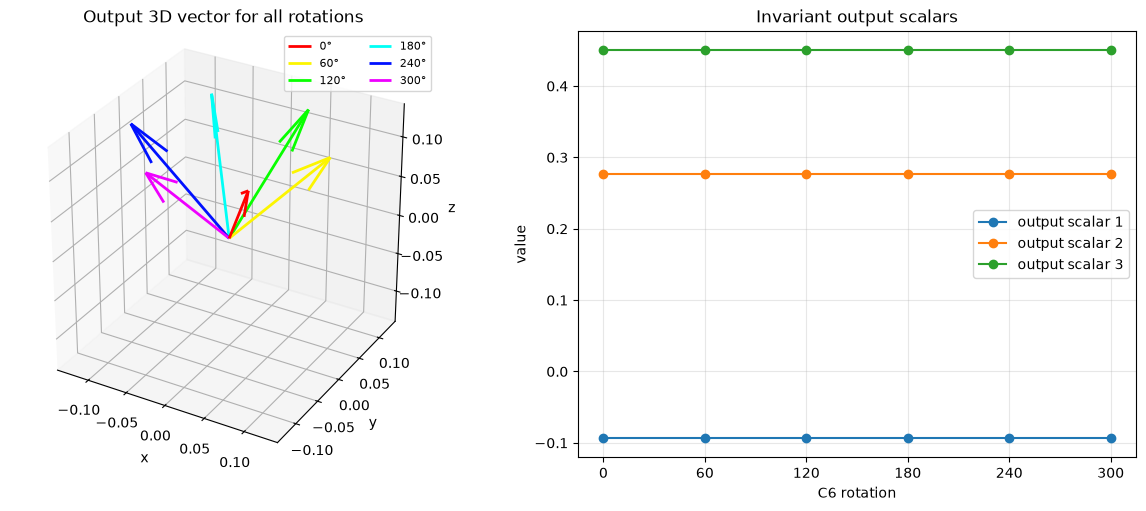

In [7]:
fig_output = plt.figure(figsize=(12, 5), constrained_layout=True)
ax_vec = fig_output.add_subplot(1, 2, 1, projection='3d')
for k, (vector, color) in enumerate(zip(output_vectors, colors)):
    ax_vec.quiver(0, 0, 0, *vector.tolist(), color=color, linewidth=2, label=f'{60*k}°')
ax_vec.set(xlabel='x', ylabel='y', zlabel='z', title='Output 3D vector for all rotations')
output_limit = max(1e-3, 1.15 * output_vectors.abs().max().item())
ax_vec.set_xlim(-output_limit, output_limit); ax_vec.set_ylim(-output_limit, output_limit); ax_vec.set_zlim(-output_limit, output_limit); ax_vec.set_box_aspect((1, 1, 1))
ax_vec.legend(ncols=2, fontsize=8)

ax_scalar = fig_output.add_subplot(1, 2, 2)
for channel in range(3):
    ax_scalar.plot(angles_deg, output_scalars[:, channel], marker='o', label=f'output scalar {channel+1}')
ax_scalar.set(xticks=angles_deg.tolist(), xlabel='C6 rotation', ylabel='value', title='Invariant output scalars')
ax_scalar.grid(alpha=0.3); ax_scalar.legend()
plt.show()